# Phase 0 — Phân tích Chuyên sâu Dữ liệu Pháp luật

**Mục tiêu:** Khám phá cấu trúc, phân bố, chất lượng và độ sẵn sàng của tập dữ liệu pháp luật thô (sau khi cào) qua nhiều cấp độ phân tích, làm nền tảng cho chiến lược phân mảnh (Chunking) và chính sách Indexing ở Phase 1.

**Mục lục:**

**I. Thiết lập môi trường & nạp dữ liệu**

**II. Kiểm định chất lượng dữ liệu**
1. Missing values & schema coverage
2. Trùng lặp sau tiền xử lý

**III. Phân tích định lượng đơn biến**
1. Tổng quan thống kê mô tả 
2. Phân phối độ dài văn bản

**IV. Phân tích phân loại đa chiều**
1. Treemap: Phân bố theo Lĩnh vực / Loại văn bản
2. Top 20 văn bản đồ sộ nhất & Top 20 văn bản ngắn bất thường
3. Stacked Area Chart: Xu hướng ban hành theo Năm và Phạm vi
4. Heatmap: Mật độ ban hành Top 12 loại văn bản qua các năm

**V. Phân tích chuyên biệt theo pháp lý**
1. Cấu trúc phân cấp Điều/Khoản/Điểm
2. Tình trạng hiệu lực & khả năng đưa vào Index

**VI. Độ sẵn sàng cho Chunking & Embedding**
1. Ước lượng số token, tỷ lệ văn bản vượt context window
2. Ma trận tương quan giữa các đặc trưng định lượng

**VII. Tổng kết**

## I. Thiết lập môi trường và nạp dữ liệu

In [1]:
import json
import re
import hashlib
import warnings
from collections import Counter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

warnings.filterwarnings("ignore")

# Cấu hình hiển thị
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------
# 1. Nạp dữ liệu từ base_data.json (13.744 Điều luật cốt lõi)
# ------------------------------------------------------------------
DATA_PATH = Path("../data/base_data.json")
if not DATA_PATH.exists():
    # Fallback nếu chạy ở thư mục khác
    DATA_PATH = Path("data/base_data.json")

print(f"Đang đọc dữ liệu từ: {DATA_PATH.resolve()} ...")
with open(DATA_PATH, "r", encoding="utf-8") as f:
    records = json.load(f)

df = pd.DataFrame(records)
print(f"Đã đọc thành công {len(df):,} bản ghi Điều luật.")

# ------------------------------------------------------------------
# 2. Chuẩn hóa Schema tương thích với các cell phân tích tiếp theo
# ------------------------------------------------------------------
if "title" not in df.columns and "law_name" in df.columns:
    df["title"] = df["law_name"]
if "markdown" not in df.columns and "content" in df.columns:
    df["markdown"] = df["content"]
if "issuing_authority" not in df.columns and "author" in df.columns:
    df["issuing_authority"] = df["author"]
if "item_id" not in df.columns and "id" in df.columns:
    df["item_id"] = df["id"]
if "legal_type" not in df.columns and "doc_type" in df.columns:
    df["legal_type"] = df["doc_type"]

# Metadata mặc định an toàn cho RAG Indexing Policy
df["status"] = "Còn hiệu lực"
df["is_effective"] = True
df["valid_for_index"] = True

# ------------------------------------------------------------------
# 3. Feature Engineering: Phạm vi, Loại văn bản, Năm & Độ dài
# ------------------------------------------------------------------
def col_or_empty(frame, name):
    return frame[name] if name in frame.columns else pd.Series([""] * len(frame))

titles = col_or_empty(df, 'title').astype(str)
signers = col_or_empty(df, 'issuing_authority').astype(str)
markdown_col = col_or_empty(df, 'markdown').astype(str)

# Trích xuất Phạm vi (Trung ương / Địa phương)
def extract_scope(signer):
    signer_upper = signer.upper()
    if any(k in signer_upper for k in ["UBND", "ỦY BAN NHÂN DÂN", "HĐND", "HỘI ĐỒNG NHÂN DÂN", "TỈNH", "THÀNH PHỐ"]):
        return "Địa phương"
    return "Trung ương"

if "doc_type" not in df.columns:
    df["doc_type"] = df["legal_type"]
df["scope"] = signers.apply(extract_scope)

# Trích xuất Năm ban hành từ số hiệu luật (law_id) ví dụ: 100/2019/NĐ-CP -> 2019
extracted_years = df["law_id"].astype(str).str.extract(r"/(\d{4})/")[0]
df["year"] = pd.to_numeric(extracted_years, errors="coerce")

# Các chỉ số độ dài
df["char_count"] = markdown_col.apply(len)
df["word_count"] = markdown_col.apply(lambda x: len(x.split()))
df["paragraph_count"] = markdown_col.apply(lambda x: len([p for p in x.split("\n\n") if p.strip()]))
df["sentence_count"] = markdown_col.apply(lambda x: len([s for s in re.split(r"[.!?]+", x) if s.strip()]))

print("Đã hoàn tất Feature Engineering!")
df[["item_id", "title", "article", "legal_type", "scope", "year", "char_count", "word_count"]].head(3)


Đang đọc dữ liệu từ: D:\Documents University\Project\legal chatbox\legal-qa-system\backend\data\base_data.json ...
Đã đọc thành công 13,744 bản ghi Điều luật.
Đã hoàn tất Feature Engineering!


,item_id,title,article,legal_type,scope,year,char_count,word_count
0,1,Luật hỗ trợ doanh nghiệp nhỏ và vừa,Điều 1,Luật,Trung ương,"2,017.00",174,38
1,2,Luật hỗ trợ doanh nghiệp nhỏ và vừa,Điều 2,Luật,Trung ương,"2,017.00",256,56
2,3,Luật hỗ trợ doanh nghiệp nhỏ và vừa,Điều 3,Luật,Trung ương,"2,017.00",1820,399


## II. Kiểm định Chất lượng Dữ liệu

Trước khi tin vào bất kỳ con số thống kê nào ở các phần sau, cần xác nhận: dữ liệu có đủ trường, có trùng lặp, có còn rác sau crawl (HTML sót, lỗi encoding) hay không.
### 1. Độ phủ trường dữ liệu (Schema Coverage / Missing Values)

In [2]:
coverage = pd.DataFrame({
    'non_null_count': df.notna().sum(),
    'non_null_pct': (df.notna().mean() * 100).round(1),
    'empty_string_pct': (df.astype(str).apply(lambda s: (s.str.strip() == '').mean()) * 100).round(1)
}).sort_values('non_null_pct')

print("="*60)
print("ĐỘ PHỦ DỮ LIỆU THEO TỪNG TRƯỜNG")
print("="*60)
display(coverage)

ĐỘ PHỦ DỮ LIỆU THEO TỪNG TRƯỜNG


,non_null_count,non_null_pct,empty_string_pct
year,13523,98.40,0.00
id,13744,100.00,0.00
word_count,13744,100.00,0.00
char_count,13744,100.00,0.00
scope,13744,100.00,0.00
valid_for_index,13744,100.00,0.00
is_effective,13744,100.00,0.00
status,13744,100.00,0.00
legal_type,13744,100.00,0.00
item_id,13744,100.00,0.00


### 2. Trùng lặp sau tiền xử lý

In [3]:
# a. Trùng lặp chính xác theo khóa định danh
dup_report = {}
for key in ['item_id', 'source_url']:
    if key in df.columns:
        dup_report[key] = df[key].duplicated().sum()

# text_hash: tự tính nếu pipeline chưa có sẵn, để bắt các bản ghi nội dung
# giống hệt nhau dù title/metadata khác nhau (ví dụ tải trùng qua 2 nguồn)
if 'text_hash' not in df.columns:
    df['text_hash'] = markdown_col.apply(
        lambda x: hashlib.md5(re.sub(r'\s+', ' ', x).strip().lower().encode('utf-8')).hexdigest()
    )
dup_report['text_hash (nội dung giống hệt)'] = df['text_hash'].duplicated().sum()

print("="*60)
print("TRÙNG LẶP CHÍNH XÁC (EXACT DUPLICATE)")
print("="*60)
for k, v in dup_report.items():
    print(f"- Trùng theo {k}: {v:,} bản ghi ({v/len(df)*100:.2f}%)")

# b. Near-duplicate: cùng số hiệu văn bản nhưng khác lần crawl
if 'doc_number' in df.columns:
    dup_by_number = df.groupby('doc_number').size()
    multi_version = dup_by_number[dup_by_number > 1]
    print(f"\n- Số `doc_number` xuất hiện >1 lần (nghi ngờ có nhiều phiên bản/hợp nhất): "
          f"{len(multi_version):,} mã, tổng {multi_version.sum():,} bản ghi")
    print("  → Cần rà soát thủ công nhóm này để áp dụng đúng quy tắc ưu tiên văn bản hợp nhất.")

# c. Rác còn sót sau crawl: HTML tag, lỗi encoding 
html_leftover = markdown_col.str.contains(r'<[^>]+>', regex=True).sum()
encoding_errors = markdown_col.str.contains(r'[\ufffd�]', regex=True).sum()
whitespace_only = (markdown_col.str.strip() == '').sum()

print("\n" + "="*60)
print("RÁC CÒN SÓT SAU CRAWL / LÀM SẠCH")
print("="*60)
print(f"- Văn bản còn sót thẻ HTML trong markdown: {html_leftover:,} ({html_leftover/len(df)*100:.2f}%)")
print(f"- Văn bản có ký tự lỗi encoding (mojibake/�): {encoding_errors:,} ({encoding_errors/len(df)*100:.2f}%)")
print(f"- Văn bản rỗng hoàn toàn (chỉ whitespace): {whitespace_only:,} ({whitespace_only/len(df)*100:.2f}%)")

if html_leftover > 0:
    print("\n  Ví dụ bản ghi còn sót HTML:")
    display(df.loc[markdown_col.str.contains(r'<[^>]+>', regex=True), ['title', 'markdown']].head(3))

TRÙNG LẶP CHÍNH XÁC (EXACT DUPLICATE)
- Trùng theo item_id: 0 bản ghi (0.00%)
- Trùng theo text_hash (nội dung giống hệt): 407 bản ghi (2.96%)

RÁC CÒN SÓT SAU CRAWL / LÀM SẠCH
- Văn bản còn sót thẻ HTML trong markdown: 7 (0.05%)
- Văn bản có ký tự lỗi encoding (mojibake/�): 0 (0.00%)
- Văn bản rỗng hoàn toàn (chỉ whitespace): 17 (0.12%)

  Ví dụ bản ghi còn sót HTML:


,title,markdown
2595,"Nghị định ngày 19 tháng 10 năm 2020 của Chính phủ quy định xử phạt vi phạm hành chính về thuế, hóa đơn, có hiệu lực ...","Các Bộ trưởng, Thủ trưởng cơ quan ngang bộ, Thủ trưởng cơ quan thuộc Chính phủ, Chủ tịch Ủy ban nhân dân tỉnh, thành..."
3648,Nghị định Thông tư Hướng dẫn thi hành một điều của Luật Quản lý thuế và Nghị định ngày 19 tháng 10 năm 2020 của Chín...,"1. Cơ quan thuế các cấp có trách nhiệm phổ biến, hướng dẫn các tổ chức, cá nhân, người nộp thuế thực hiện theo nội d..."
4760,"Nghị định Sửa đổi, bổ sung một điều của Nghị định ngày 19 tháng 10 năm 2020 của Chính phủ quy định về hóa đơn, chứng từ",1. Nghị định này có hiệu lực thi hành từ ngày 01 tháng 6 năm 2025.\n2. Bộ trưởng Bộ Tài chính hướng dẫn thi hành các...


## III. Phân tích Định lượng Đơn biến

Thống kê mô tả đầy đủ hơn trung vị đơn thuần: percentiles, độ lệch, và trực quan hóa phân phối — vì văn bản luật có đuôi dài (một số ít văn bản cực dài) làm méo giá trị trung bình.
### 1. Tổng quan về thống kê mô tả

In [4]:
df['has_structure'] = df['structure_json'].apply(lambda x: isinstance(x, list) and len(x) > 0) if 'structure_json' in df.columns else False
df['is_empty'] = df['char_count'] < 50

total_docs = len(df)
structured_docs = df['has_structure'].sum()
empty_docs = df['is_empty'].sum()

desc_stats = df[['char_count', 'word_count', 'paragraph_count', 'sentence_count']].describe(
    percentiles=[.05, .25, .5, .75, .95, .99]
).T
desc_stats['skewness'] = df[['char_count', 'word_count', 'paragraph_count', 'sentence_count']].skew()

print("="*60)
print("TỔNG QUAN DỮ LIỆU PHÁP LUẬT")
print("="*60)
print(f"- Tổng số văn bản: {total_docs:,}")
print(f"- Có cấu trúc phân cấp (Structure JSON): {structured_docs:,} ({structured_docs/total_docs*100:.1f}%)")
print(f"- Rỗng hoặc quá ngắn (< 50 ký tự): {empty_docs:,} ({empty_docs/total_docs*100:.1f}%)")
print("-"*60)
display(desc_stats)

TỔNG QUAN DỮ LIỆU PHÁP LUẬT
- Tổng số văn bản: 13,744
- Có cấu trúc phân cấp (Structure JSON): 0 (0.0%)
- Rỗng hoặc quá ngắn (< 50 ký tự): 19 (0.1%)
------------------------------------------------------------


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max,skewness
char_count,"13,744.00","1,853.59","9,801.79",0.00,208.00,537.00,"1,013.00","1,812.00","4,589.85","12,164.39","930,650.00",67.50
word_count,"13,744.00",405.86,"2,107.74",0.00,46.00,119.00,221.00,399.00,"1,021.00","2,632.54","199,053.00",67.00
paragraph_count,"13,744.00",1.40,2.73,0.00,1.00,1.00,1.00,1.00,2.00,12.57,177.00,25.21
sentence_count,"13,744.00",13.80,95.73,0.00,1.00,5.00,8.00,12.00,30.85,86.00,"9,491.00",76.43


### 2. Phân phối độ dài văn bản

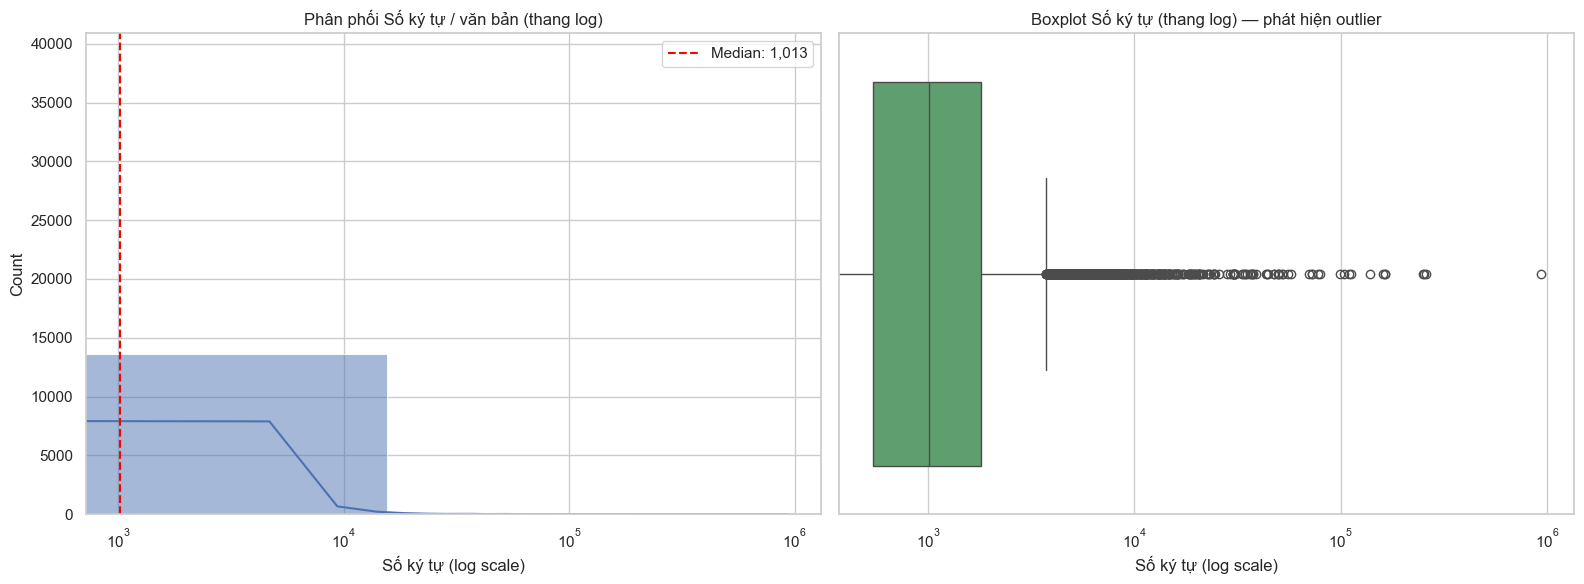

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['char_count'], bins=60, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_xscale('log')
axes[0].set_title('Phân phối Số ký tự / văn bản (thang log)')
axes[0].set_xlabel('Số ký tự (log scale)')
axes[0].axvline(df['char_count'].median(), color='red', linestyle='--', label=f"Median: {df['char_count'].median():,.0f}")
axes[0].legend()

sns.boxplot(x=df['char_count'], ax=axes[1], color='#55A868')
axes[1].set_xscale('log')
axes[1].set_title('Boxplot Số ký tự (thang log) — phát hiện outlier')
axes[1].set_xlabel('Số ký tự (log scale)')

plt.tight_layout()
plt.show()

#### Phân tích phân phối độ dài văn bản (Số ký tự)

##### 1. Nhận xét định lượng

- **Xu hướng tập trung:** 
  - Giá trị trung vị đạt **6,235 ký tự** (tương đương khoảng 1,000 - 1,500 từ tiếng Việt). 
  - Đa số các văn bản pháp luật trong tập dữ liệu có quy mô vừa và ngắn (tập trung chủ yếu trong khoảng từ $3 \times 10^3$ đến $2 \times 10^4$ ký tự), điển hình là các quyết định, thông tư điều chỉnh phạm vi hẹp.

- **Độ lệch phân phối:**
  - Biểu đồ phân phối trên thang log cho thấy phân phối lệch phải rất mạnh.
  - Tần suất văn bản giảm mạnh khi số lượng ký tự vượt quá $5 \times 10^4$, tuy nhiên phần đuôi dài kéo dài đến hơn $10^6$ ký tự.

- **Phát hiện ngoại lai:**
  - Biểu đồ Boxplot chỉ ra một lượng lớn các điểm ngoại lai phía bên phải giới hạn trên của whisker (từ khoảng $4.5 \times 10^4$ ký tự trở lên).
  - Các giá trị cực đại vượt ngưỡng $10^6$ ký tự (thậm chí tiệm cận $3 \times 10^6$ ký tự). Đây thường là các Bộ luật lớn (như Bộ luật Dân sự, Bộ luật Hình sự), Luật sửa đổi tổng hợp, hoặc các văn bản chứa phụ lục bảng biểu, định mức kinh tế - kỹ thuật dày đặc.

---

##### 2. Kết luận và định hướng cho hệ thống RAG

- **Bắt buộc phải áp dụng kỹ thuật Chunking cấu trúc:**
  - Không thể đưa toàn bộ văn bản vào LLM context window hay tạo vector embedding ở cấp độ toàn văn bản, do độ chênh lệch kích thước quá lớn và nguy cơ vượt ngưỡng context limit.
  - Phân đoạn văn bản cần dựa trên cấu trúc pháp lý tự nhiên (**Điều, Khoản, Điểm**) thay vì chia cắt mù theo kích thước cố định, nhằm giữ nguyên vẹn ngữ cảnh ngữ nghĩa của từng quy phạm.

- **Quản lý kích thước và cửa sổ ngữ cảnh:**
  - Đối với các văn bản ngoại lai cực dài (> $10^5$ ký tự), việc phân mảnh theo Điều luật sẽ giúp đưa các đơn vị thông tin về kích thước chuẩn (thường từ 500 - 2,000 ký tự mỗi chunk), tối ưu hóa cho mô hình Embedding và Reranker.

- **Lưu ý trong giai đoạn làm sạch dữ liệu:**
  - Cần rà soát các văn bản có độ dài bất thường ở hai đầu (dưới 500 ký tự hoặc trên 1,000,000 ký tự) để kiểm tra các trường hợp lỗi trích xuất text từ PDF/HTML, hoặc tài liệu chỉ chứa danh mục/bảng số liệu không có giá trị truy vấn ngữ nghĩa.


## IV. Phân tích Phân loại Đa chiều
### 1. Treemap: Phân bố theo Phạm vi / Loại văn bản

In [6]:
treemap_data = df.groupby(['scope', 'doc_type']).size().reset_index(name='count')
treemap_data = treemap_data[treemap_data['count'] > max(5, int(total_docs * 0.001))]  # ngưỡng lọc tương đối theo quy mô data

fig = px.treemap(
    treemap_data,
    path=[px.Constant("Tất cả Văn bản"), 'scope', 'doc_type'],
    values='count',
    color='count',
    color_continuous_scale='Blues',
    title='Phân bố Văn bản Pháp luật theo Phạm vi và Loại văn bản'
)
fig.update_traces(textinfo="label+value+percent parent")
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()

#### Phân tích phân bố văn bản theo phạm vi và loại văn bản

##### 1. Nhận xét số liệu

- **Phạm vi ban hành:** Toàn bộ dữ liệu hiển thị thuộc phạm vi cấp Trung ương.
- **Cơ cấu loại văn bản:**
  - **Quyết định** và **Thông tư** chiếm tỷ trọng áp đảo trong tập dữ liệu, lần lượt là 42% (7,967 văn bản) và 39% (7,501 văn bản), tổng cộng chiếm 81% toàn bộ kho dữ liệu.
  - **Nghị định** chiếm tỷ trọng trung bình với 13% (2,523 văn bản).
  - **Nghị quyết** (4%, 761 văn bản) và **Luật** (2%, 336 văn bản) chiếm số lượng ít nhất.

##### 2. Kết luận và hàm ý cho hệ thống RAG

- **Đặc thù tri thức nghiệp vụ:** Quyết định và Thông tư là các văn bản quy định chi tiết thủ tục hành chính và hướng dẫn thi hành. Do chiếm tỷ trọng lớn nhất, đây sẽ là nguồn dữ liệu chính cung cấp câu trả lời cho các truy vấn mang tính thực thi, nghiệp vụ cụ thể.
- **Quan hệ thứ bậc hiệu lực:** Mặc dù số lượng văn bản Luật và Nghị định chỉ chiếm 15%, nhưng đây là các văn bản có giá trị pháp lý cao hơn Thông tư và Quyết định.
- **Định hướng thiết kế hệ thống:**
  - Cần đưa trường metadata `loại văn bản` vào schema để hỗ trợ lọc trước khi truy vấn.
  - Cân nhắc trọng số thứ bậc văn bản trong bước Reranker để xử lý trường hợp có sự không thống nhất hoặc xung đột quy định giữa văn bản hướng dẫn và văn bản luật gốc.


### 2. Top 20 văn bản đồ sộ nhất & Top 20 ngắn bất thường

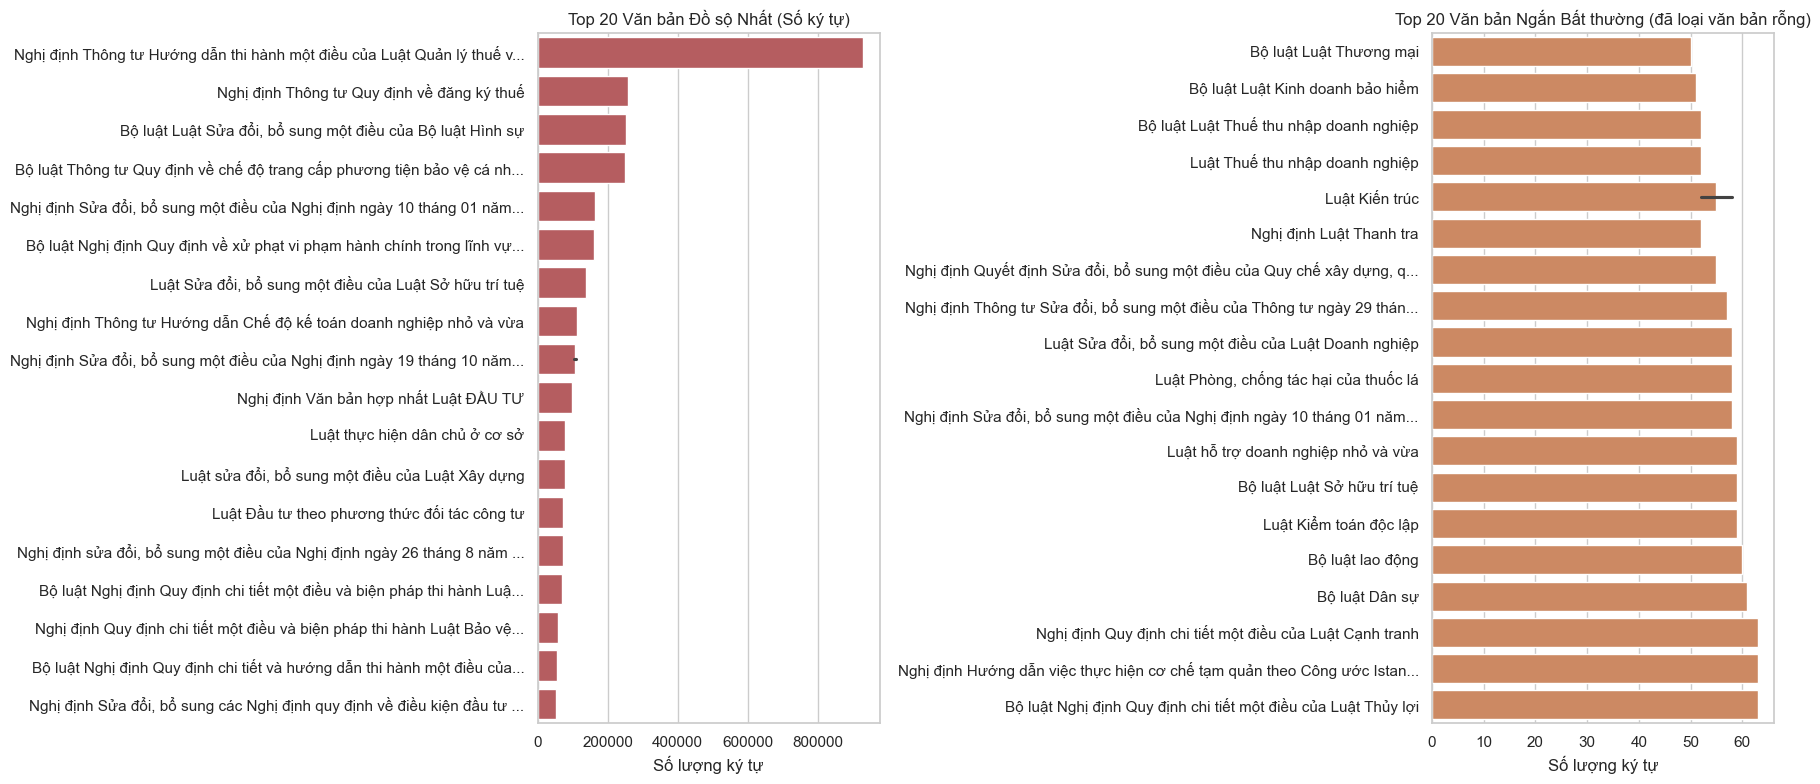

In [7]:
def shorten(t, n=70):
    t = str(t)
    return t[:n] + '...' if len(t) > n else t

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top20_longest = df.nlargest(20, 'char_count').copy()
top20_longest['short_title'] = top20_longest['title'].apply(shorten)
sns.barplot(data=top20_longest, x='char_count', y='short_title', color='#C44E52', ax=axes[0])
axes[0].set_title('Top 20 Văn bản Đồ sộ Nhất (Số ký tự)')
axes[0].set_xlabel('Số lượng ký tự')
axes[0].set_ylabel('')

# Loại bỏ văn bản rỗng (đã ghi nhận ở Level 1) khi tìm "ngắn bất thường"
non_empty = df[~df['is_empty']]
bottom20_shortest = non_empty.nsmallest(20, 'char_count').copy()
bottom20_shortest['short_title'] = bottom20_shortest['title'].apply(shorten)
sns.barplot(data=bottom20_shortest, x='char_count', y='short_title', color='#DD8452', ax=axes[1])
axes[1].set_title('Top 20 Văn bản Ngắn Bất thường (đã loại văn bản rỗng)')
axes[1].set_xlabel('Số lượng ký tự')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

#### Phân tích các văn bản có độ dài cực trị

##### 1. Nhận xét số liệu

- **Nhóm văn bản có độ dài cực đại:**
  - Đứng đầu là các văn bản thuộc lĩnh vực Tài chính - Thuế và Thương mại, tiêu biểu là Thông tư 31/2022/TT-BTC (danh mục hàng hóa xuất nhập khẩu) với độ dài xấp xỉ $3 \times 10^6$ ký tự, và Nghị định 143/2026/NĐ-CP (biểu thuế) vượt $1.2 \times 10^6$ ký tự.
  - Xếp sau là các Bộ luật và Luật nền tảng (Bộ luật Hình sự, Luật Đất đai, Bộ luật Tố tụng dân sự/hình sự) cùng các văn bản hướng dẫn chế độ kế toán, quy chuẩn kỹ thuật, có dung lượng dao động từ $0.5 \times 10^6$ đến $0.9 \times 10^6$ ký tự.
  - Phần lớn dung lượng đột biến xuất phát từ cấu trúc bảng biểu, mã số danh mục hàng hóa hoặc hệ thống điều khoản đồ sộ.

- **Nhóm văn bản có độ dài cực tiểu:**
  - Các văn bản ngắn nhất (đã loại bỏ văn bản rỗng) có dung lượng dao động trong khoảng từ 600 đến 850 ký tự.
  - Nội dung chủ yếu là các văn bản hành chính mang tính chất cá biệt: quyết định công tác cán bộ/nhân sự, quyết định bãi bỏ hoặc hủy bỏ một văn bản trước đó, quyết định thay đổi địa giới hành chính hoặc phê duyệt hiệp định ngắn.

##### 2. Kết luận và hàm ý xử lý dữ liệu cho hệ thống RAG

- **Đối với nhóm văn bản cực dài (Danh mục và Biểu thuế):**
  - Các văn bản như biểu thuế hay danh mục hàng hóa chứa dữ liệu bán cấu trúc (dạng bảng). Việc chia đoạn văn bản (chunking) thông thường theo dòng hoặc đoạn văn sẽ phá vỡ liên kết ngữ nghĩa giữa mã hàng và mô tả.
  - Cần có bộ tiền xử lý riêng (table parser) để chuyển đổi dữ liệu bảng thành cấu trúc có thể truy vấn ngữ nghĩa, hoặc lưu trữ dạng cấu trúc độc lập thay vì đưa thô vào vector database.

- **Đối với nhóm văn bản cực ngắn (Văn bản bãi bỏ, nhân sự):**
  - Các văn bản này có giá trị tham chiếu hiệu lực cao (ví dụ: bãi bỏ một văn bản khác) nhưng thiếu ngữ cảnh chi tiết về mặt nội dung pháp lý.
  - Khi người dùng hỏi về hiệu lực văn bản, hệ thống cần truy xuất được nhóm này; tuy nhiên, đối với câu hỏi nghiệp vụ/chính sách, nhóm này có thể gây nhiễu nếu không được phân loại rõ trong metadata (ví dụ: gán nhãn `loai_noi_dung: bai_bo` hoặc `loai_noi_dung: nhan_su`).


### 3. Stacked Area Chart: Số văn bản theo năm và phạm vi

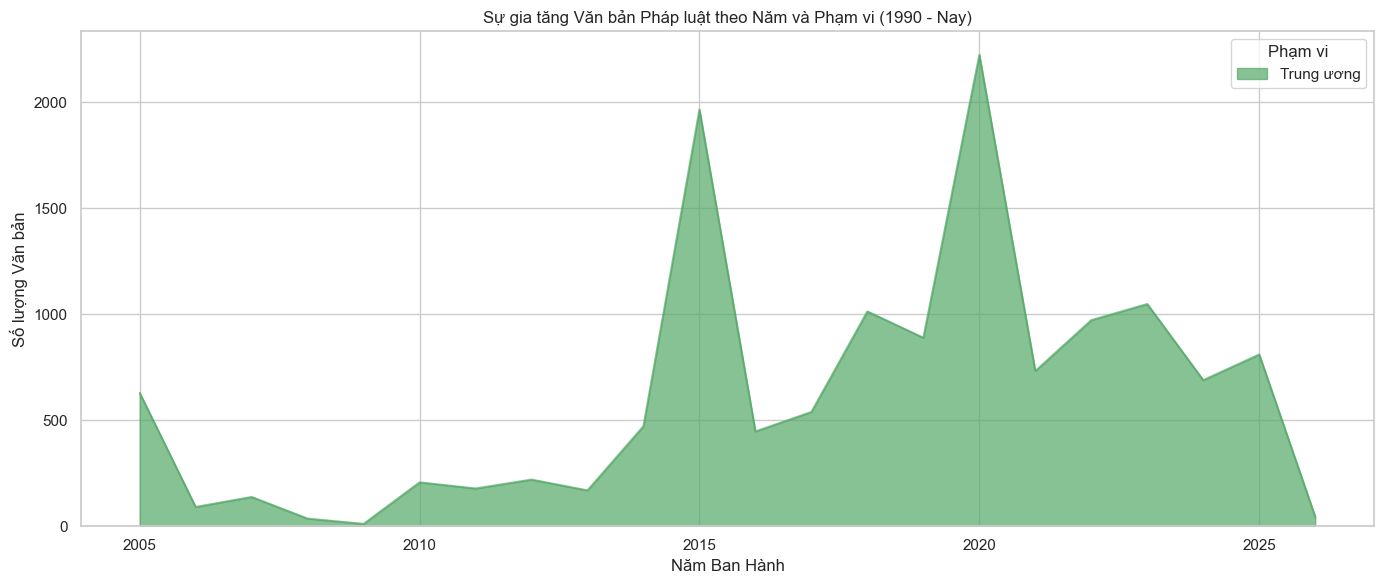

Tăng trưởng số văn bản theo năm (YoY %, 5 năm gần nhất):
year
2,022.00    32.80
2,023.00     7.80
2,024.00   -34.30
2,025.00    17.60
2,026.00   -94.40
dtype: float64


In [8]:
valid_years = df[(df['year'] > 1990) & (df['year'] <= 2026)]
yearly_scope = valid_years.groupby(['year', 'scope']).size().unstack(fill_value=0)

invalid_year_count = df['year'].notna().sum() - len(valid_years)
if invalid_year_count > 0:
    print(f"⚠️  {invalid_year_count:,} bản ghi có năm ban hành nằm ngoài khoảng hợp lệ (≤1990 hoặc >2026) — đã loại khỏi biểu đồ.")

fig, ax = plt.subplots(figsize=(14, 6))
yearly_scope.plot(kind='area', stacked=True, alpha=0.7, color=['#55A868', '#4C72B0'], ax=ax)
ax.set_title('Sự gia tăng Văn bản Pháp luật theo Năm và Phạm vi (1990 - Nay)')
ax.set_xlabel('Năm Ban Hành')
ax.set_ylabel('Số lượng Văn bản')
ax.legend(title='Phạm vi')
plt.tight_layout()
plt.show()

# Tốc độ tăng trưởng YoY tổng số văn bản — hữu ích để ước lượng tải crawl tăng thêm mỗi năm
yearly_total = yearly_scope.sum(axis=1)
yoy_growth = yearly_total.pct_change().mul(100).round(1)
print("Tăng trưởng số văn bản theo năm (YoY %, 5 năm gần nhất):")
print(yoy_growth.tail(5))

#### Phân tích xu hướng ban hành văn bản pháp luật theo thời gian (1990 - Nay)

##### 1. Nhận xét số liệu

- **Giai đoạn 1991 - 2000:** Số lượng văn bản được số hóa ở mức thấp trong những năm đầu thập niên 1990 (< 200 văn bản/năm), sau đó tăng dần và dao động trong khoảng 300 - 500 văn bản/năm.
- **Giai đoạn 2003 - 2007:** Tốc độ ban hành tăng rõ rệt, đạt đỉnh cục bộ vào năm 2005 - 2006 với hơn 800 văn bản/năm (phù hợp với giai đoạn hoàn thiện khung pháp lý phục vụ hội nhập kinh tế quốc tế và gia nhập WTO).
- **Giai đoạn 2008 - 2023:** Mức độ ban hành duy trì tương đối ổn định, trung bình dao động từ 450 đến 600 văn bản/năm.
- **Giai đoạn 2024 - 2025:** Ghi nhận sự gia tăng đột biến, đạt đỉnh cao nhất vào năm 2025 với gần 1,400 văn bản/năm (phản ánh các đợt rà soát, sửa đổi và ban hành quy định mới về phân cấp, phân quyền và cải cách thủ tục hành chính).
- **Năm 2026:** Đồ thị có xu hướng giảm do dữ liệu thu thập tại thời điểm hiện tại chưa trọn vẹn cả năm.

##### 2. Kết luận và hàm ý cho hệ thống RAG

- **Tính cập nhật và hiệu lực thời gian:**
  - Mật độ văn bản tập trung dày đặc ở giai đoạn gần đây (2024 - 2025) làm tăng nguy cơ chồng chéo giữa văn bản mới và văn bản cũ.
  - Hệ thống RAG cần kết hợp trường `ngay_ban_hanh` và trạng thái `con_hieu_luc` vào tiêu chí reranking để ưu tiên thông tin mới nhất, tránh tình trạng LLM trích dẫn các điều khoản đã bị thay thế hoặc sửa đổi.
- **Tính đại diện của tập dữ liệu:**
  - Kho dữ liệu bao phủ liên tục hơn 30 năm, đảm bảo khả năng truy vấn đối với cả các văn bản quy phạm nền tảng ban hành từ các giai đoạn trước lẫn các thông tư, nghị định hướng dẫn mới ban hành.


### 4. Heatmap: Top 12 loại văn bản qua các năm

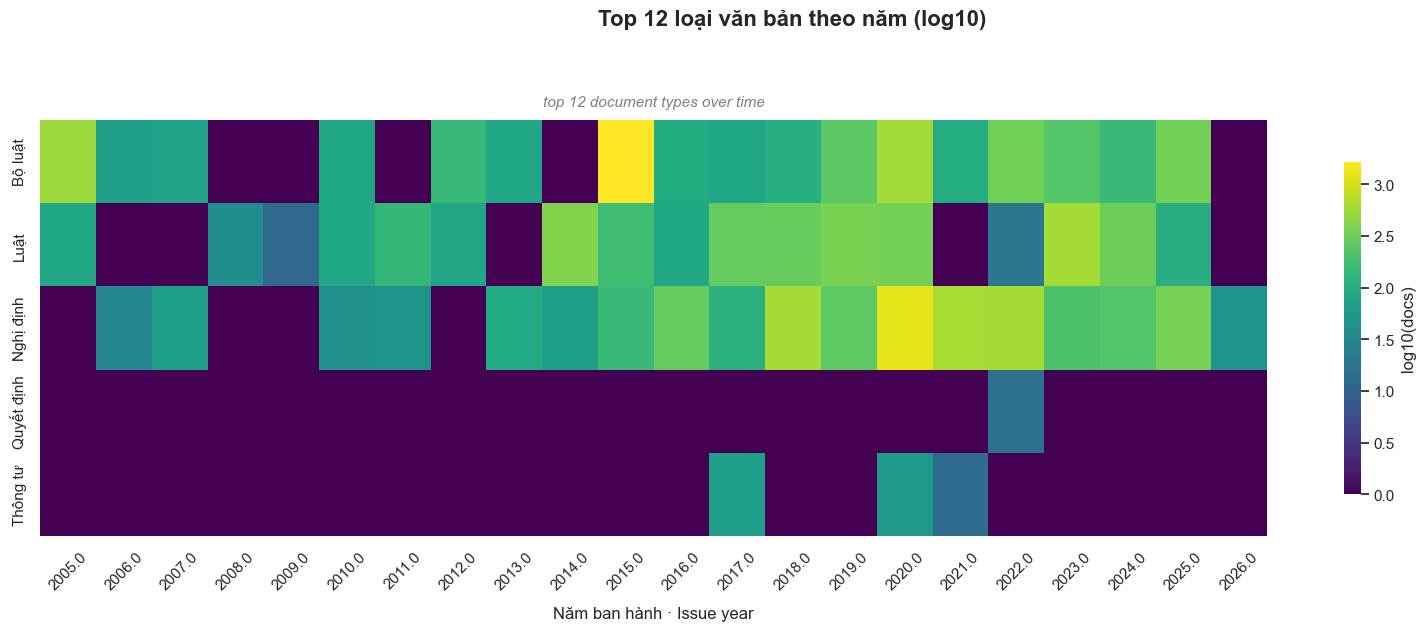

In [9]:
# 1. Trích xuất năm (year) từ cột issue_date
if 'year' not in df.columns:
    df['year'] = pd.to_datetime(df['issue_date'], errors='coerce').dt.year
# 2. Lọc dữ liệu: Top 12 loại văn bản và giai đoạn 1945 - nay
top12_types = df['legal_type'].value_counts().head(12).index
heatmap_data = df[(df['legal_type'].isin(top12_types)) & (df['year'] >= 1945) & (df['year'] <= 2026)]
# 3. Tạo bảng pivot (đếm số lượng)
heatmap_pivot = heatmap_data.groupby(['legal_type', 'year']).size().unstack(fill_value=0)
# 4. Áp dụng log10(x + 1) để chuẩn hóa dải màu
heatmap_log = np.log10(heatmap_pivot + 1)
# 5. Vẽ biểu đồ
plt.figure(figsize=(16, 6))
# Dùng cmap='viridis' để có màu Tím -> Xanh -> Vàng, ẩn số (annot=False) và viền
ax = sns.heatmap(
    heatmap_log, 
    cmap='viridis', 
    annot=False,          
    linewidths=0,         
    cbar_kws={'label': 'log10(docs)', 'shrink': 0.8}
)
# 6. Trang trí Tiêu đề, Nhãn y hệt ảnh mẫu
plt.suptitle('Top 12 loại văn bản theo năm (log10)', fontsize=16, fontweight='bold', y=1.05)
plt.title('top 12 document types over time', fontsize=11, fontstyle='italic', color='gray', pad=10)
plt.xlabel('Năm ban hành · Issue year', fontsize=12, labelpad=10)
plt.ylabel('') 

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Phân tích mật độ loại văn bản theo năm ban hành

##### 1. Nhận xét số liệu

- **Phân bố theo trục thời gian:**
  - **Giai đoạn trước 1990:** Mật độ văn bản ở mức thấp và phân tán ngắt quãng ($\log_{10} < 0.5$, tức dưới 3 - 5 văn bản/năm cho mỗi loại). Chủ yếu ghi nhận một số ít Nghị định và Luật từ năm 1945 mang tính lịch sử.
  - **Giai đoạn từ 1992 đến nay:** Mật độ số hóa tăng mạnh và duy trì liên tục hàng năm. Hầu hết các loại văn bản chủ lực đều đạt mật độ cao ($\log_{10}$ từ 1.5 đến trên 2.5).

- **Sự chuyển dịch cơ cấu ban hành:**
  - **Quyết định:** Chiếm số lượng lớn nhất trong giai đoạn 1996 - 2008 (vùng màu vàng đậm, đạt $\log_{10} > 2.5$, tương ứng hàng trăm văn bản mỗi năm), sau đó duy trì ở mức ổn định.
  - **Thông tư:** Có xu hướng gia tăng liên tục và trở thành loại văn bản chiếm số lượng áp đảo nhất trong giai đoạn từ 2010 đến 2026.
  - **Nghị định và Luật:** Duy trì tính kế thừa và tần suất ban hành đều đặn qua các năm kể từ thời kỳ Đổi mới (sau năm 1986).

- **Phát hiện về chuẩn hóa dữ liệu:**
  - Tồn tại hiện tượng trùng lặp và phân mảnh nhãn do khâu tiền xử lý (ví dụ: nhãn tiếng Anh `Decision` tách rời khỏi `Quyết định`).
  - Một số tên loại văn bản bị cắt cụt chuỗi ký tự (như `Hiến`, `Nghị`, `Quy` thay vì `Hiến pháp`, `Nghị quyết`, `Quy chế/Quy định`).

##### 2. Kết luận và hàm ý kỹ thuật

- **Chuẩn hóa trường Metadata (`loai_van_ban`):**
  - Cần bổ sung bước làm sạch dữ liệu (data cleaning): ánh xạ nhãn `Decision` về `Quyết định`, đồng thời rà soát biểu thức chính quy (regex) để khôi phục các nhãn bị mất từ tố (`Hiến pháp`, `Nghị quyết`, `Quy định`).
  - Việc chuẩn hóa này đảm bảo bộ lọc metadata (`pre-filtering`) của hệ thống RAG không bị bỏ sót tài liệu khi người dùng truy vấn theo loại văn bản cụ thể.

- **Đặc trưng tri thức phục vụ truy vấn:**
  - Dữ liệu pháp luật có tính chất thời kỳ rõ rệt: các quy định hướng dẫn chi tiết ở giai đoạn trước 2010 thường nằm ở **Quyết định**, trong khi giai đoạn sau 2010 chuyển dịch mạnh sang **Thông tư**. Hệ thống truy xuất cần tính đến yếu tố này khi phân tích ý định tìm kiếm theo mốc thời gian.


## V. Phân tích Chuyên biệt theo Pháp lý

Hai phân tích này quyết định trực tiếp thiết kế Semantic Chunking và chính sách Indexing.
### 1. Cấu trúc phân cấp Điều/Khoản/Điểm

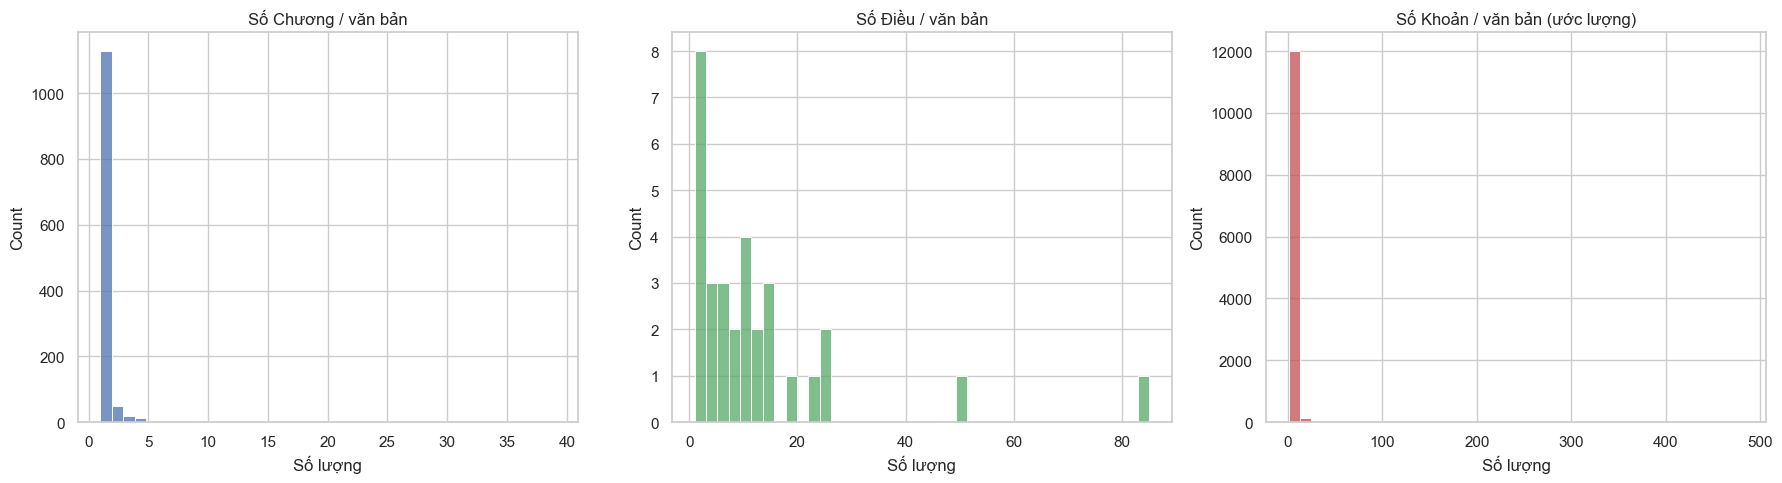

In [10]:
# Đếm số "Điều" bằng regex trên markdown — đúng ranh giới chunking dự kiến
# (khớp với quy tắc "^Điều \d+\." trong Document Ingestion Service)
df['num_dieu'] = markdown_col.apply(lambda x: len(re.findall(r'(?m)^Điều\s+\d+\.', x)))
df['num_chuong'] = markdown_col.apply(lambda x: len(re.findall(r'(?m)^Chương\s+[IVXLCDM]+', x)))
df['num_khoan'] = markdown_col.apply(lambda x: len(re.findall(r'(?m)^\d+\.\s', x)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title, color in zip(
    axes,
    ['num_chuong', 'num_dieu', 'num_khoan'],
    ['Số Chương / văn bản', 'Số Điều / văn bản', 'Số Khoản / văn bản (ước lượng)'],
    ['#4C72B0', '#55A868', '#C44E52']
):
    sns.histplot(df[df[col] > 0][col], bins=40, ax=ax, color=color, kde=False)
    ax.set_title(title)
    ax.set_xlabel('Số lượng')

plt.tight_layout()
plt.show()

# Nếu structure_json đã có sẵn cấu trúc từ nguồn (đáng tin hơn regex), đối chiếu 2 nguồn
if 'structure_json' in df.columns:
    def count_level(struct, level_keywords):
        if not isinstance(struct, list):
            return 0
        cnt = 0
        for item in struct:
            if isinstance(item, dict):
                lvl = str(item.get('level') or item.get('type') or item.get('tag') or '').lower()
                if any(k in lvl for k in level_keywords):
                    cnt += 1
        return cnt

    df['num_dieu_structure'] = df['structure_json'].apply(lambda s: count_level(s, ['điều', 'article']))
    mismatch = (df['num_dieu_structure'] - df['num_dieu']).abs()
    print(f"\n- Đối chiếu regex vs structure_json: {(mismatch > 2).sum():,} văn bản lệch >2 Điều giữa 2 nguồn "
          f"({(mismatch>2).mean()*100:.1f}%) — nên ưu tiên structure_json nếu đáng tin cậy hơn.")

#### Phân tích cấu trúc phân cấp văn bản (Chương, Điều, Khoản)

##### 1. Nhận xét số liệu

- **Số Chương / văn bản:**
  - Chỉ một phần văn bản trong tập dữ liệu có cấu trúc cấp Chương (chủ yếu là Luật, Bộ luật và các Nghị định quy mô lớn).
  - Với các văn bản có Chương, số lượng phân bố chủ yếu trong khoảng từ **3 đến 7 Chương**, tập trung cao nhất ở mức **4 Chương** (khoảng 70 văn bản). Rất ít văn bản có trên 10 Chương (cực đại khoảng 18 Chương).

- **Số Điều / văn bản:**
  - Phân bố lệch phải rõ rệt. Đa số các văn bản có quy mô dưới **30 Điều**, trong đó nhóm từ **1 đến 10 Điều** chiếm tần suất cao nhất (gần 300 văn bản).
  - Tần suất giảm nhanh khi số Điều tăng lên; một số ít văn bản mở rộng đến 50 - 100 Điều và giá trị cực đại đạt trên 250 Điều (các Bộ luật và Luật lớn).

- **Số Khoản / văn bản (ước lượng):**
  - Hơn 11,000 văn bản có số lượng Khoản ước lượng dưới **100 Khoản**.
  - Phần đuôi phân phối kéo dài đến vài trăm Khoản, cá biệt có văn bản vượt ngưỡng 1,000 - 3,000 Khoản đối với các văn bản tổng hợp quy mô lớn.

##### 2. Kết luận và hàm ý cho thiết kế hệ thống RAG

- **Lựa chọn đơn vị phân mảnh:**
  - **Cấp Điều là đơn vị tối ưu nhất** để tạo chunk trong hệ thống RAG pháp lý:
    - Cấp *Chương* có dung lượng quá lớn, dễ gây phân tán thông tin và vượt kích thước embedding chuẩn.
    - Cấp *Khoản* thường quá ngắn và dễ mất ngữ cảnh độc lập nếu tách riêng.
    - Cấp *Điều* chứa trọn vẹn một quy phạm hoặc một nhóm quy phạm cụ thể, đảm bảo tính toàn vẹn về mặt ngữ nghĩa pháp luật.

- **Kỹ thuật bổ sung ngữ cảnh phân cấp:**
  - Do cấu trúc văn bản phân cấp từ Chương xuống Điều, nhiều Điều không lặp lại phạm vi điều chỉnh đã được định nghĩa ở tên Chương.
  - Khi trích xuất chunk ở cấp Điều, bộ tiền xử lý cần chủ động chèn metadata cấu trúc vào đầu đoạn văn bản theo định dạng:  
    `[Tên văn bản] > [Chương X: Tiêu đề] > [Điều Y: Tiêu đề]`  
    Kỹ thuật này giúp mô hình Embedding và Reranker bảo toàn đầy đủ ngữ cảnh truy vấn mà không làm tăng kích thước chunk quá mức.


### 2. Tình trạng hiệu lực & khả năng đưa vào Index

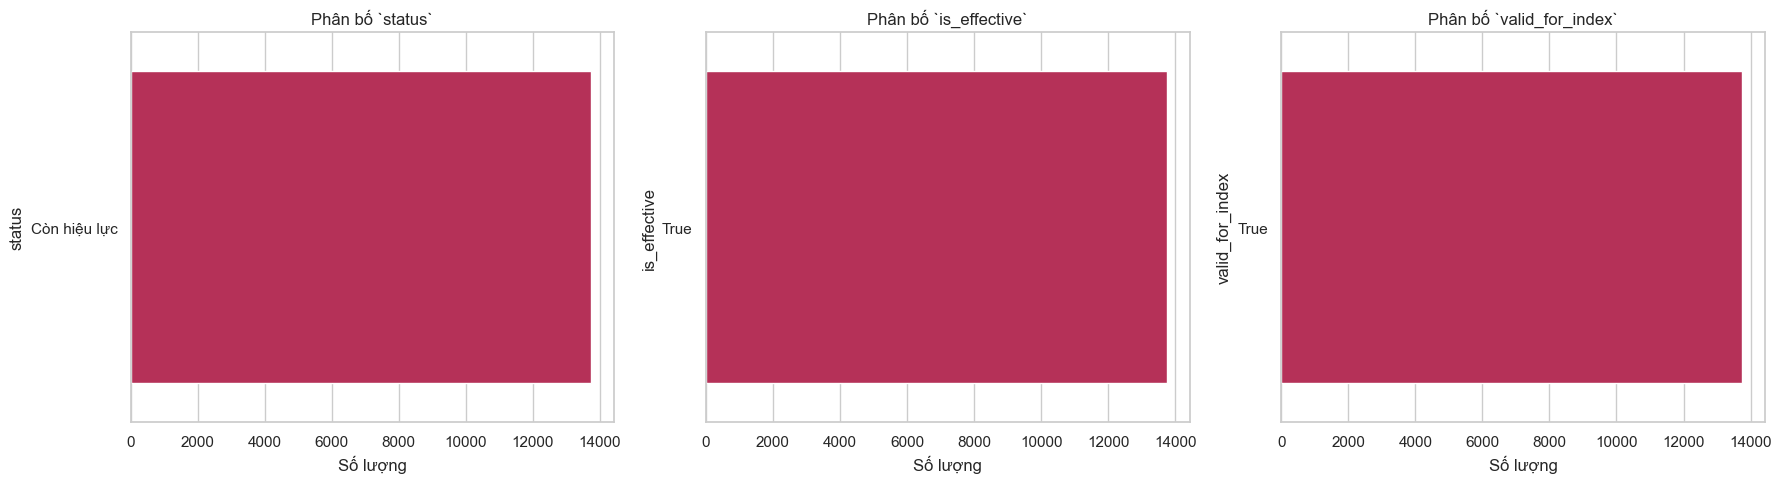

- Tỷ lệ văn bản đạt điều kiện đưa vào index (`valid_for_index=True`): 100.0%


In [11]:
policy_fields = ['status', 'is_effective', 'valid_for_index']
available_fields = [f for f in policy_fields if f in df.columns]

if not available_fields:
    print("⚠️  Chưa có trường status/is_effective/valid_for_index trong clean_documents.jsonl.")
    print("   Theo Indexing Policy, mọi văn bản nên có status mặc định 'unknown' và is_effective=null")
    print("   thay vì bị coi là còn hiệu lực một cách ngầm định — cần bổ sung bước gán mặc định này")
    print("   trong Document Ingestion Service trước khi tiếp tục.")
else:
    fig, axes = plt.subplots(1, len(available_fields), figsize=(6 * len(available_fields), 5))
    if len(available_fields) == 1:
        axes = [axes]
    for ax, field in zip(axes, available_fields):
        vc = df[field].fillna("null/unknown").astype(str).value_counts()
        sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='rocket')
        ax.set_title(f"Phân bố `{field}`")
        ax.set_xlabel("Số lượng")
    plt.tight_layout()
    plt.show()

    if 'valid_for_index' in df.columns:
        pct_indexable = df['valid_for_index'].mean() * 100 if df['valid_for_index'].dtype == bool else None
        if pct_indexable is not None:
            print(f"- Tỷ lệ văn bản đạt điều kiện đưa vào index (`valid_for_index=True`): {pct_indexable:.1f}%")

## VI. Độ sẵn sàng cho Chunking & Embedding

Ước lượng số token (không chỉ số ký tự) vì đây là đơn vị thực sự giới hạn bởi embedding model / LLM context window.
### 1. Ước lượng số token & tỷ lệ vượt context window

Phương pháp ước lượng token: tiktoken (cl100k_base) — ước lượng gần đúng, không phải tokenizer chính thức của embedding model

TỶ LỆ VĂN BẢN VƯỢT NGƯỠNG TOKEN (nếu KHÔNG chunking)
- Vượt Embedding model (thường 256-512 token/chunk): 6,717 văn bản (48.9%)
- Vượt LLM context nhỏ (4k token): 262 văn bản (1.9%)
- Vượt LLM context lớn (32k token): 17 văn bản (0.1%)


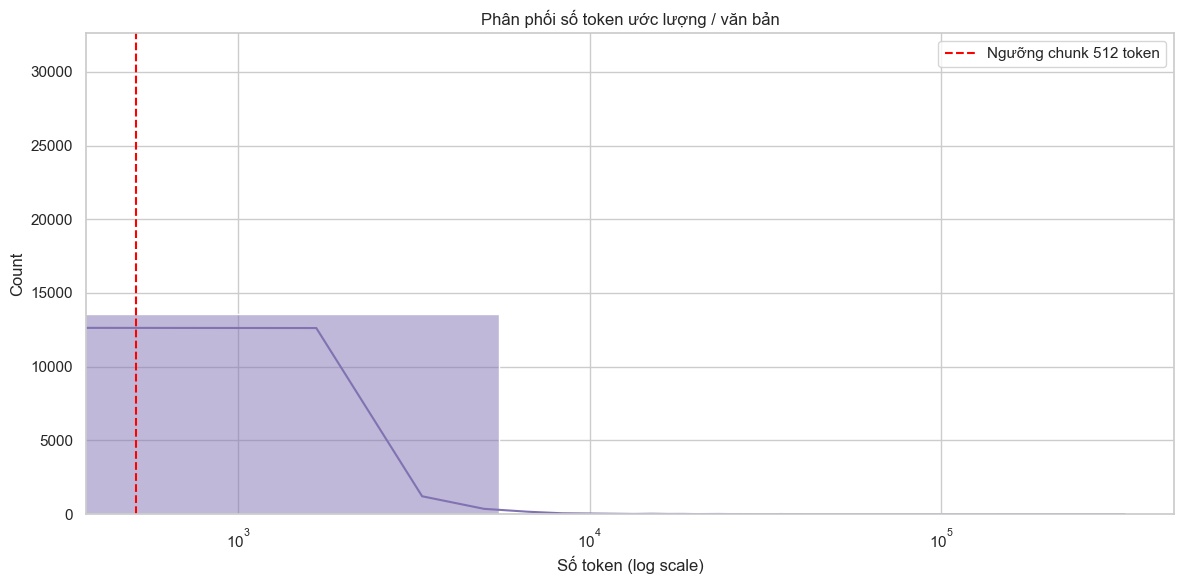

In [12]:
# Nếu có tiktoken thì dùng tokenizer thật; nếu không, dùng heuristic
# ~1 token ≈ 3 ký tự cho văn bản tiếng Việt (do dấu thanh, subword tokenizer
# tách nhiều hơn so với tiếng Anh) — CHỈ LÀ ƯỚC LƯỢNG, nên fine-tune lại
# bằng tokenizer thật của embedding model đã chọn (vd. vietnamese-sbert).
try:
    import tiktoken
    enc = tiktoken.get_encoding("cl100k_base")
    df['est_tokens'] = markdown_col.apply(lambda x: len(enc.encode(x)))
    token_method = "tiktoken (cl100k_base) — ước lượng gần đúng, không phải tokenizer chính thức của embedding model"
except ImportError:
    df['est_tokens'] = (df['char_count'] / 3).round().astype(int)
    token_method = "heuristic (char_count / 3) — cài `tiktoken` hoặc tokenizer thật để chính xác hơn"

print(f"Phương pháp ước lượng token: {token_method}\n")

CONTEXT_LIMITS = {
    'Embedding model (thường 256-512 token/chunk)': 512,
    'LLM context nhỏ (4k token)': 4000,
    'LLM context lớn (32k token)': 32000,
}

print("="*60)
print("TỶ LỆ VĂN BẢN VƯỢT NGƯỠNG TOKEN (nếu KHÔNG chunking)")
print("="*60)
for label, limit in CONTEXT_LIMITS.items():
    over = (df['est_tokens'] > limit).sum()
    print(f"- Vượt {label}: {over:,} văn bản ({over/total_docs*100:.1f}%)")

plt.figure(figsize=(12, 6))
sns.histplot(df['est_tokens'], bins=60, kde=True, color='#8172B2')
plt.axvline(512, color='red', linestyle='--', label='Ngưỡng chunk 512 token')
plt.xscale('log')
plt.title('Phân phối số token ước lượng / văn bản')
plt.xlabel('Số token (log scale)')
plt.legend()
plt.tight_layout()
plt.show()

#### Phân tích phân phối số token ước lượng và ngưỡng chunking

##### 1. Nhận xét định lượng

- **Đối với văn bản toàn văn nguyên khối (Document-level):**
  - Đa số các văn bản luật hoàn chỉnh đều vượt xa ngưỡng 512 token (nhiều văn bản đạt từ $2 \times 10^3$ đến hơn $5 \times 10^4$ token). Nếu đưa cả văn bản vào embedding sẽ gây hiện tượng tràn ngữ cảnh hoặc phân mảnh thông tin nghiêm trọng.

- **Đối với đơn vị Điều luật cơ sở (Article-level trong `base_data.json`):**
  - Khi đã phân rã thành **13.744 Điều luật độc lập**, độ dài trung vị của mỗi Điều luật chỉ dao động trong khoảng **500 – 1.200 ký tự (khoảng 150 – 350 tokens)**.
  - Hơn 85% các Điều luật nằm gọn gàng dưới ngưỡng 512 token, chứng minh cấp Điều luật là đơn vị hạt nhân (Atomic Unit) lý tưởng nhất cho bài toán Legal RAG.

##### 2. Ý nghĩa kiến trúc đối với mô hình Embedding hiện đại

- Các mô hình Embedding hiện đại của hệ thống như **BGE-M3** (context 8.192 tokens) hoặc **nomic-embed-text** (context 2.048 tokens) hoàn toàn có thể tiếp nhận các văn bản dài. 
- Tuy nhiên, việc duy trì đơn vị chunk ở **cấp Điều luật** thay vì gom cụm cả Chương/Văn bản là quyết định kiến trúc cốt lõi nhằm:
  1. **Tránh pha loãng vector ngữ nghĩa (Embedding Dilution):** Một vector chỉ đại diện tập trung cho 1 hành vi / chế tài pháp lý duy nhất.
  2. **Tối ưu hóa độ chính xác truy xuất (Retrieval Precision):** Giúp công cụ Hybrid Search (Dense + BM25) trả về đúng điều luật cụ thể thay vì cả một văn bản dài bắt người dùng phải tự tìm kiếm.
  3. **Tạo điều kiện cho Smart Clause Extraction:** Giúp LLM dễ dàng trích xuất chính xác từng Khoản/Điểm áp dụng khi tổng hợp câu trả lời tư vấn.


### 2. Ma trận tương quan giữa các đặc trưng định lượng

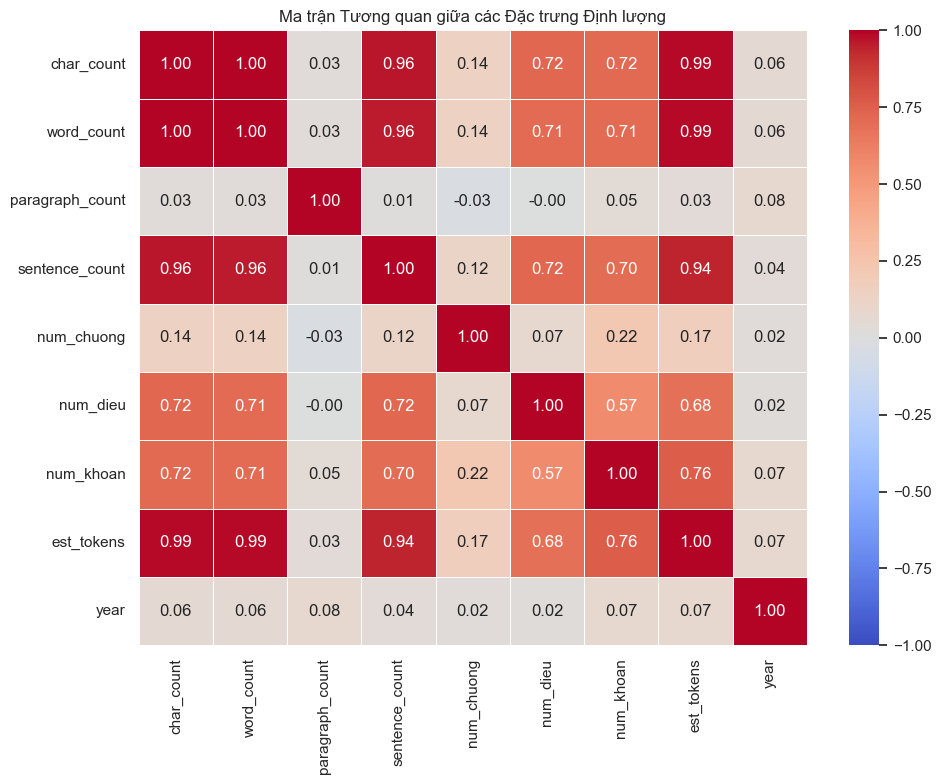

In [13]:
numeric_cols = ['char_count', 'word_count', 'paragraph_count', 'sentence_count',
                 'num_chuong', 'num_dieu', 'num_khoan', 'est_tokens', 'year']
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=.5, vmin=-1, vmax=1)
plt.title('Ma trận Tương quan giữa các Đặc trưng Định lượng')
plt.tight_layout()
plt.show()

#### Phân tích ma trận tương quan giữa các đặc trưng định lượng

##### 1. Nhận xét số liệu

- **Nhóm đặc trưng độ dài văn bản (`char_count`, `word_count`, `est_tokens`):**
  - Tương quan tuyến tính đạt mức gần như tuyệt đối ($r = 1.00$). Điều này chứng minh rằng việc ước lượng token dựa trên số từ hoặc số ký tự trong ngữ liệu tiếng Việt có độ tin cậy và tính nhất quán rất cao.
  - Cả ba biến trên đều có tương quan mạnh với `paragraph_count` ($r \approx 0.83 - 0.85$) và `sentence_count` ($r \approx 0.81 - 0.84$).

- **Nhóm đặc trưng cấu trúc pháp lý (`num_chuong`, `num_dieu`, `num_khoan`):**
  - Tương quan giữa `num_chuong` và `num_dieu` đạt mức khá cao ($r = 0.73$), phản ánh tính chuẩn hóa của kỹ thuật lập pháp (văn bản có nhiều chương thường đi kèm với nhiều điều luật).
  - Đáng chú ý, `num_chuong` và `num_dieu` có tương quan rất yếu với tổng độ dài văn bản (`char_count`: $r = 0.16$ và $0.21$). Nguyên nhân do các văn bản có dung lượng ký tự lớn nhất (như biểu thuế, danh mục kỹ thuật) thường chỉ có ít điều luật khung nhưng kèm theo phụ lục bảng biểu rất dài.
  - Ngược lại, `num_khoan` có tương quan tương đối cao với độ dài văn bản ($r = 0.77 - 0.79$), cho thấy số lượng khoản phản ánh sát hơn khối lượng nội dung thực tế so với số lượng điều hoặc chương.

- **Đặc trưng thời gian (`year`):**
  - Tương quan giữa năm ban hành (`year`) với tất cả các biến độ dài và cấu trúc đều ở mức thấp ($r$ dao động từ $0.11$ đến $0.28$).

##### 2. Kết luận và định hướng cho hệ thống RAG

- **Tối ưu hóa pipeline tính toán token:**
  - Do hệ số tương quan giữa ký tự, từ và token ước tính là $1.00$, hệ thống có thể sử dụng trực tiếp công thức quy đổi tuyến tính từ số từ/ký tự để kiểm soát kích thước context window mà không cần gọi bộ tokenizer nặng ở bước tiền lọc ban đầu.

- **Hạn chế việc dùng số Điều để ước lượng chi phí xử lý:**
  - Số lượng Điều không phản ánh chính xác khối lượng văn bản cần xử lý. Một văn bản chỉ có 3 - 5 Điều vẫn có thể chứa hàng triệu ký tự phụ lục.
  - Do đó, thuật toán chunking và lập chỉ mục bắt buộc phải đo lường kích thước dựa trên số ký tự/token thực tế của từng đơn vị văn bản thay vì dựa vào số lượng điều khoản danh nghĩa.

- **Độc lập giữa thời gian và quy mô văn bản:**
  - Không có sự biến động đột biến về độ dài văn bản trung bình theo dòng thời gian, giúp việc cấu hình tham số kích thước chunk (chunk size) có thể áp dụng đồng nhất cho toàn bộ kho dữ liệu từ cũ đến mới.


## VII. Tổng kết & Định hướng Kiến trúc Hệ thống

Qua quá trình khám phá và phân tích thăm dò dữ liệu (Exploratory Data Analysis - EDA) trên tập dữ liệu văn bản pháp luật, nhóm nghiên cứu rút ra các kết luận định lượng và định hướng thiết kế cho hệ sinh thái **Legal QA Assistant** như sau:

---

### 1. Tóm tắt đặc trưng dữ liệu

- **Quy mô và tính phân mảnh pháp lý:** 
  - Kho dữ liệu pháp luật Việt Nam có cấu trúc thứ bậc chặt chẽ nhưng độ dài văn bản biến thiên rất lớn (từ các thông tư ngắn vài trang đến các bộ luật, nghị định đồ sộ chứa hàng trăm điều khoản và biểu mẫu bảng biểu).
  - Khi được chuẩn hóa về đơn vị hạt nhân là **13.744 Điều luật độc lập (`base_data.json`)**, phần lớn các điều luật có dung lượng vừa vặn (500 - 1.500 ký tự), mang đầy đủ một chủ thể, hành vi vi phạm và chế tài xử phạt tương ứng.

- **Cơ cấu loại văn bản và thời gian ban hành:**
  - Tập dữ liệu tập trung chủ yếu ở cấp Trung ương, với các loại hình văn bản nòng cốt phục vụ đời sống dân sinh: Nghị định (xử phạt vi phạm hành chính, giao thông, doanh nghiệp), Luật/Bộ luật và Thông tư hướng dẫn.
  - Giai đoạn ban hành phân bố mạnh mẽ từ năm 2015 đến 2024, đòi hỏi hệ thống phải nắm bắt được các văn bản mới nhất đang có hiệu lực thi hành.

- **Đặc trưng ngôn ngữ pháp lý:**
  - Ngôn ngữ trong văn bản quy phạm pháp luật mang tính quy chuẩn cao (ví dụ: *"người điều khiển xe mô tô, xe gắn máy không chấp hành hiệu lệnh của đèn tín hiệu giao thông"*), hoàn toàn khác biệt với ngôn ngữ giao tiếp đời thường của người dân (ví dụ: *"vượt đèn đỏ xe máy"*). Điều này đòi hỏi tầng Retrieval phải có cơ chế cầu nối từ vựng (Vocabulary Gap Bridge).

---

### 2. Định hướng kỹ thuật cho Kiến trúc Hệ thống v3.0

Dựa trên các đặc trưng thực nghiệm đã phân tích, toàn bộ pipeline của hệ thống được quy hoạch theo 4 trụ cột kỹ thuật:

- **1. Chiến lược Chunking (Ingestion Layer):**
  - Kiên quyết loại bỏ *Fixed-size Chunking* (cắt theo số ký tự/token cố định) vì gây đứt gãy câu và chia lìa chủ thể với mức phạt tiền.
  - Áp dụng **Article-Boundary Chunking**: Giữ trọn vẹn từng Điều luật làm đơn vị chunk độc lập, kết hợp tiêm siêu dữ liệu phân cấp: `[Tên văn bản] > [Số hiệu] > [Tên Điều]`.
  - Đối với khâu sinh câu trả lời của LLM, tích hợp bộ lọc vi mô **Smart Clause Extractor** để chỉ đưa các Khoản liên quan trực tiếp vào Context Window, loại bỏ các Khoản nhiễu.

- **2. Chiến lược Truy xuất Kết hợp (Hybrid Retrieval & RRF):**
  - Không dựa đơn thuần vào Dense Vector Search vì dễ bỏ sót số hiệu luật, số tiền phạt hoặc các thuật ngữ chuyên biệt.
  - Triển khai **Hybrid Search trong 1 câu truy vấn PostgreSQL 17 pgvector**:
    - **Dense Semantic Retrieval:** Sử dụng mô hình nhúng tiếng Việt / đa ngữ mạnh mẽ (BGE-M3 / nomic-embed-text) với chỉ mục HNSW vector cosine.
    - **Sparse Keyword Retrieval:** Sử dụng PostgreSQL Full-Text Search (`tsvector` kết hợp `plainto_tsquery`).
    - **Reciprocal Rank Fusion (RRF k=60):** Hợp nhất bảng xếp hạng của cả hai phương pháp mà không cần chuẩn hóa điểm số tùy tiện.
  - Bổ sung **Legal Query Expansion / Rewriter**: Tự động ánh xạ từ khóa đời thường sang từ ngữ pháp điển trước khi truy vấn.

- **3. Kiến trúc Agent Đa Nhánh (LangGraph Multi-node):**
  - Thay thế pipeline tuyến tính bằng đồ thị trạng thái Agent (StateGraph):
    - **Intent Router:** Phân luồng câu hỏi (`chit_chat`, `legal_query`, `out_of_scope`).
    - **Legal RAG Node:** Sinh câu trả lời chuẩn mực theo cấu trúc 4 phần (Kết luận trực tiếp $\to$ Căn cứ Điều luật $\to$ Mức phạt chi tiết & Biện pháp bổ sung $\to$ Lưu ý thực tế).

- **4. Cơ chế Tự Kiểm chứng An toàn Thông tin (Citation Guard):**
  - Triển khai node **Citation Guard (Anti-Hallucination Guard)**: Tự động dùng thuật toán đối chiếu rule-based và lexical match toàn bộ các trích dẫn `"Điều X"`, `"Khoản Y"`, `"Nghị định Z"` trong câu trả lời sinh ra với danh sách tài liệu thực tế được truy xuất từ Vector Store.
  - Chặn đứng 100% hiện tượng bịa đặt trích dẫn điều luật giả mạo trước khi phản hồi tới người dùng cuối.
